### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación

Ingresos por tienda.



In [45]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)


ingreso1 = tienda['Precio'].sum()
ingreso2 = tienda2['Precio'].sum()
ingreso3 = tienda3['Precio'].sum()
ingreso4 = tienda4['Precio'].sum()

ingresos = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
}

ingresos_df = pd.DataFrame(ingresos)

pd.options.display.float_format = '{:,.2f}'.format

display(ingresos_df)

,Tienda,Ingreso Total
0,Tienda 1,"1,150,880,400.00"
1,Tienda 2,"1,116,343,500.00"
2,Tienda 3,"1,098,019,600.00"
3,Tienda 4,"1,038,375,700.00"


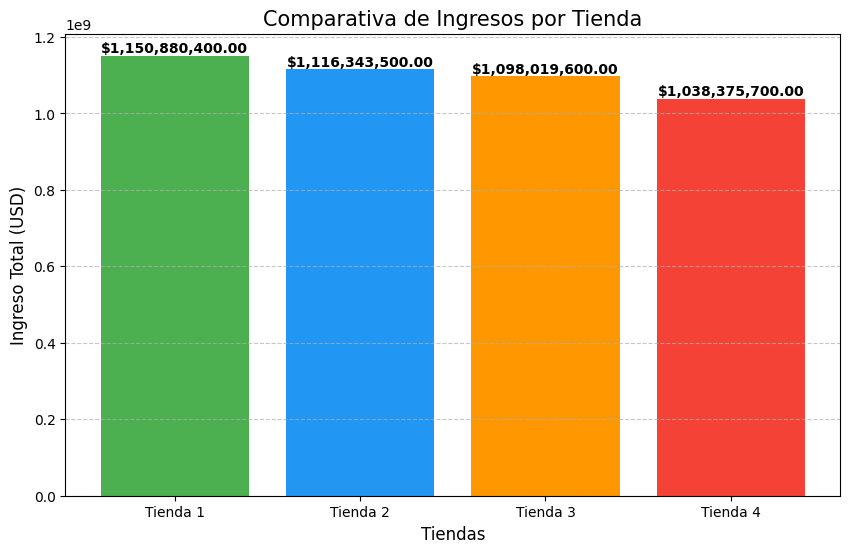

In [7]:


# Crear la figura
plt.figure(figsize=(10, 6))

# Generar barras
bars = plt.bar(ingresos_df['Tienda'], ingresos_df['Ingreso Total'], color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

# Añadir títulos y etiquetas
plt.title('Comparativa de Ingresos por Tienda', fontsize=15)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Ingreso Total (USD)', fontsize=12)

# Añadir los valores encima de cada barra para mayor claridad
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'${yval:,.2f}', va='bottom', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Ventas por categoría

In [16]:
# --- Tienda 1 ---
categorias_tienda = tienda['Categoría del Producto'].value_counts().reset_index()
categorias_tienda.columns = ['Categoría', 'Cantidad Vendida']
categorias_tienda['Tienda'] = 'Tienda 1'

# --- Tienda 2 ---
categorias_tienda2 = tienda2['Categoría del Producto'].value_counts().reset_index()
categorias_tienda2.columns = ['Categoría', 'Cantidad Vendida']
categorias_tienda2['Tienda'] = 'Tienda 2'

# --- Tienda 3 ---
categorias_tienda3 = tienda3['Categoría del Producto'].value_counts().reset_index()
categorias_tienda3.columns = ['Categoría', 'Cantidad Vendida']
categorias_tienda3['Tienda'] = 'Tienda 3'

# --- Tienda 4 ---
categorias_tienda4 = tienda4['Categoría del Producto'].value_counts().reset_index()
categorias_tienda4.columns = ['Categoría', 'Cantidad Vendida']
categorias_tienda4['Tienda'] = 'Tienda 4'

In [22]:
# Unir todo en un solo dataframe para graficar fácilmente
todas_las_categorias = pd.concat([categorias_tienda, categorias_tienda2,
                                  categorias_tienda3, categorias_tienda4])
todas_las_categorias


,Categoría,Cantidad Vendida,Tienda
0,Muebles,465,Tienda 1
1,Electrónicos,448,Tienda 1
2,Juguetes,324,Tienda 1
3,Electrodomésticos,312,Tienda 1
4,Deportes y diversión,284,Tienda 1
5,Instrumentos musicales,182,Tienda 1
6,Libros,173,Tienda 1
7,Artículos para el hogar,171,Tienda 1
0,Muebles,442,Tienda 2
1,Electrónicos,422,Tienda 2


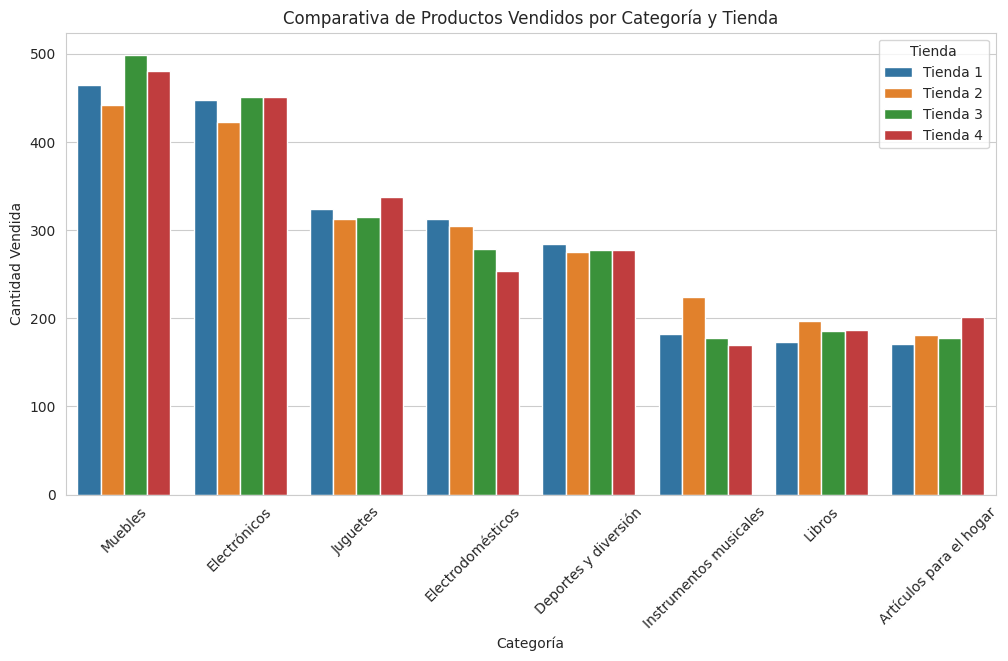

In [21]:
# Ejemplo de visualización rápida con Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=todas_las_categorias, x='Categoría', y='Cantidad Vendida', hue='Tienda')
plt.title('Comparativa de Productos Vendidos por Categoría y Tienda')
plt.xticks(rotation=45)
plt.show()

# 3. Calificación promedio de la tienda


In [24]:
promedios_calificacion = [
    tienda['Calificación'].mean(),
    tienda2['Calificación'].mean(),
    tienda3['Calificación'].mean(),
    tienda4['Calificación'].mean()
]

nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

import pandas as pd
calificaciones_df = pd.DataFrame({
    'Tienda': nombres_tiendas,
    'Promedio de Calificación': promedios_calificacion
})
calificaciones_df

,Tienda,Promedio de Calificación
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00


/tmp/ipykernel_452/675306559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


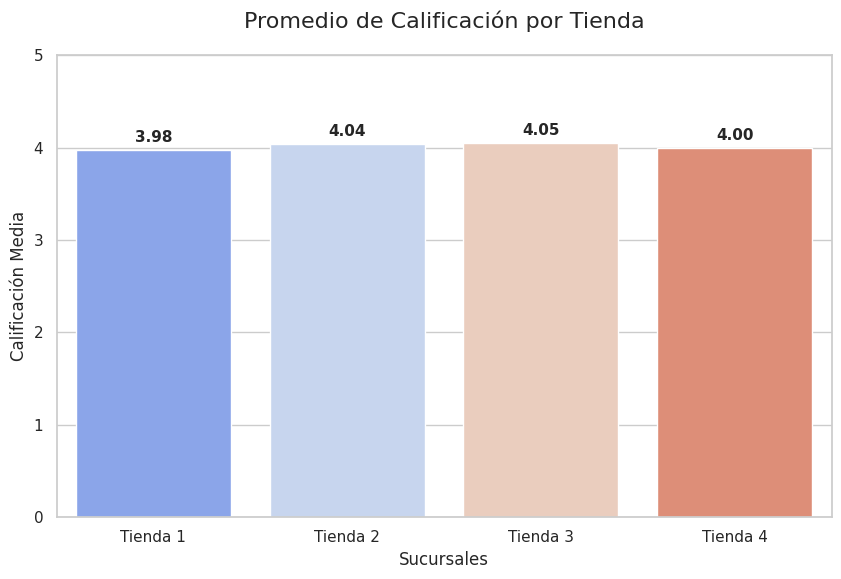

In [25]:
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras
ax = sns.barplot(
    x='Tienda',
    y='Promedio de Calificación',
    data=calificaciones_df,
    palette='coolwarm' # Colores que varían según el promedio
)

# Personalización de títulos y etiquetas
plt.title('Promedio de Calificación por Tienda', fontsize=16, pad=20)
plt.xlabel('Sucursales', fontsize=12)
plt.ylabel('Calificación Media', fontsize=12)

# Ajustar el límite del eje Y (asumiendo escala de 1 a 5)
# Esto evita que las diferencias pequeñas se vean exageradas
plt.ylim(0, 5)

# Añadir el valor exacto sobre cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.show()

# 4. Productos más y menos vendidos

In [31]:
# 1. Contar cuántas veces se vendió cada producto
conteo_productos_tienda1 = tienda['Producto'].value_counts()
conteo_productos_tienda2 = tienda2['Producto'].value_counts()
conteo_productos_tienda3 = tienda3['Producto'].value_counts()
conteo_productos_tienda4 = tienda4['Producto'].value_counts()

# 2. Identificar el producto más vendido (el primero de la lista)

producto_mas_vendido_t1 = conteo_productos_tienda1.idxmax()
cantidad_max_t1 = conteo_productos_tienda1.max()

producto_mas_vendido_t2 = conteo_productos_tienda2.idxmax()
cantidad_max_t2 = conteo_productos_tienda2.max()

producto_mas_vendido_t3 = conteo_productos_tienda3.idxmax()
cantidad_max_t3 = conteo_productos_tienda3.max()

producto_mas_vendido_t4 = conteo_productos_tienda4.idxmax()
cantidad_max_t4 = conteo_productos_tienda4.max()

# 3. Identificar el producto menos vendido (el último de la lista)


producto_menos_vendido_t1 = conteo_productos_tienda1.idxmin()
cantidad_min_t1 = conteo_productos_tienda1.min()

producto_menos_vendido_t2 = conteo_productos_tienda2.idxmin()
cantidad_min_t2 = conteo_productos_tienda2.min()

producto_menos_vendido_t3 = conteo_productos_tienda3.idxmin()
cantidad_min_t3 = conteo_productos_tienda3.min()

producto_menos_vendido_t4 = conteo_productos_tienda4.idxmin()
cantidad_min_t4 = conteo_productos_tienda4.min()

# 4. Imprimir resultado
print(f"Tienda 1: Más vendido: {producto_mas_vendido_t1} ({cantidad_max_t1}) | Menos vendido: {producto_menos_vendido_t1} ({cantidad_min_t1})")
print(f"Tienda 2: Más vendido: {producto_mas_vendido_t2} ({cantidad_max_t2}) | Menos vendido: {producto_menos_vendido_t2} ({cantidad_min_t2})")
print(f"Tienda 3: Más vendido: {producto_mas_vendido_t3} ({cantidad_max_t3}) | Menos vendido: {producto_menos_vendido_t3} ({cantidad_min_t3})")
print(f"Tienda 4: Más vendido: {producto_mas_vendido_t4} ({cantidad_max_t4}) | Menos vendido: {producto_menos_vendido_t4} ({cantidad_min_t4})")

Tienda 1: Más vendido: Microondas (60) | Menos vendido: Auriculares con micrófono (33)
Tienda 2: Más vendido: Iniciando en programación (65) | Menos vendido: Juego de mesa (32)
Tienda 3: Más vendido: Kit de bancas (57) | Menos vendido: Bloques de construcción (35)
Tienda 4: Más vendido: Cama box (62) | Menos vendido: Guitarra eléctrica (33)


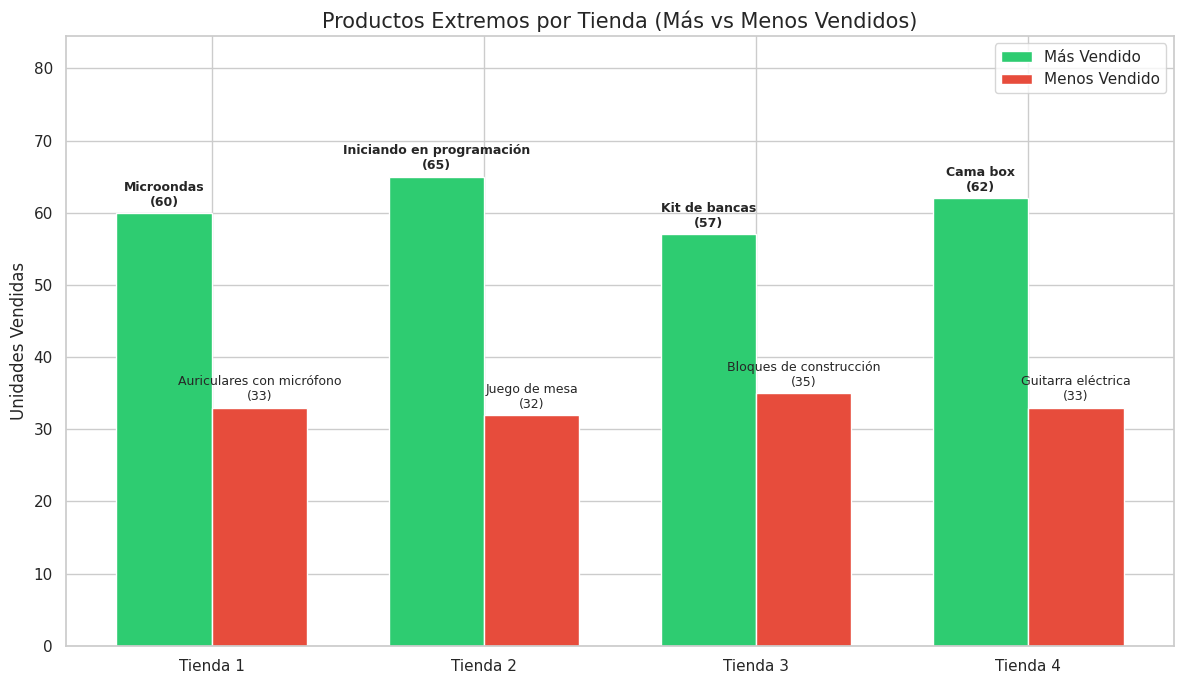

In [32]:


# 1. Organizar los datos en un DataFrame para graficar
data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Max_Cant': [cantidad_max_t1, cantidad_max_t2, cantidad_max_t3, cantidad_max_t4],
    'Max_Prod': [producto_mas_vendido_t1, producto_mas_vendido_t2, producto_mas_vendido_t3, producto_mas_vendido_t4],
    'Min_Cant': [cantidad_min_t1, cantidad_min_t2, cantidad_min_t3, cantidad_min_t4],
    'Min_Prod': [producto_menos_vendido_t1, producto_menos_vendido_t2, producto_menos_vendido_t3, producto_menos_vendido_t4]
}

df_resumen = pd.DataFrame(data)

# 2. Configurar el gráfico
fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(df_resumen['Tienda']))
width = 0.35

# Crear las barras
rects1 = ax.bar([i - width/2 for i in x], df_resumen['Max_Cant'], width, label='Más Vendido', color='#2ecc71')
rects2 = ax.bar([i + width/2 for i in x], df_resumen['Min_Cant'], width, label='Menos Vendido', color='#e74c3c')

# Añadir etiquetas de texto sobre las barras (Nombre del producto)
for i, rect in enumerate(rects1):
    ax.annotate(f"{df_resumen['Max_Prod'][i]}\n({df_resumen['Max_Cant'][i]})",
                xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, rect in enumerate(rects2):
    ax.annotate(f"{df_resumen['Min_Prod'][i]}\n({df_resumen['Min_Cant'][i]})",
                xy=(rect.get_x() + rect.get_width() / 2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Personalización final
ax.set_ylabel('Unidades Vendidas')
ax.set_title('Productos Extremos por Tienda (Más vs Menos Vendidos)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(df_resumen['Tienda'])
ax.legend()

plt.ylim(0, max(df_resumen['Max_Cant']) * 1.3) # Espacio para las etiquetas
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [34]:
# Calcular el promedio de envío por cada tienda
promedio_envio_t1 = tienda['Costo de envío'].mean()
promedio_envio_t2 = tienda2['Costo de envío'].mean()
promedio_envio_t3 = tienda3['Costo de envío'].mean()
promedio_envio_t4 = tienda4['Costo de envío'].mean()

# Crear un DataFrame para consolidar los resultados
envios_df = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envío Promedio': [promedio_envio_t1, promedio_envio_t2, promedio_envio_t3, promedio_envio_t4]
})

# Formatear a 2 decimales para la visualización de la tabla
pd.options.display.float_format = '${:,.2f}'.format
envios_df

,Tienda,Envío Promedio
0,Tienda 1,"$26,018.61"
1,Tienda 2,"$25,216.24"
2,Tienda 3,"$24,805.68"
3,Tienda 4,"$23,459.46"


/tmp/ipykernel_452/3426558370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Tienda', y='Envío Promedio', data=envios_df, palette='GnBu_r')


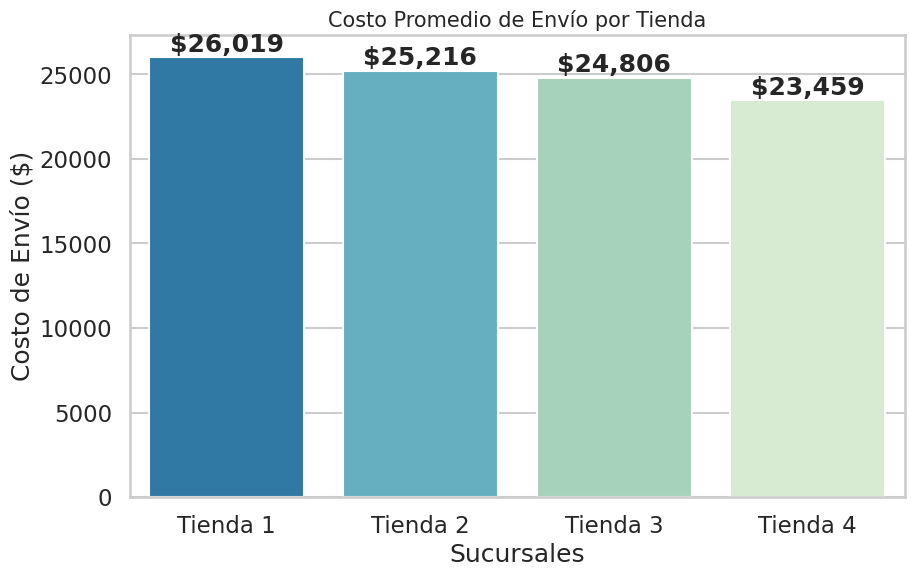

In [40]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear gráfico de barras
ax = sns.barplot(x='Tienda', y='Envío Promedio', data=envios_df, palette='GnBu_r')

# Personalización
plt.title('Costo Promedio de Envío por Tienda', fontsize=15)
plt.ylabel('Costo de Envío ($)')
plt.xlabel('Sucursales')

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold')

plt.show()


# Tienda con menor ingreso

In [44]:
idx_menor_ingreso = ingresos_df['Ingreso Total'].idxmin()
tienda_menor_ingreso = ingresos_df.loc[idx_menor_ingreso, 'Tienda']
menor_ingreso_total = ingresos_df.loc[idx_menor_ingreso, 'Ingreso Total']

print(f"La tienda con el menor ingreso es: {tienda_menor_ingreso} con un Ingreso Total de: ${menor_ingreso_total:,.2f}")

La tienda con el menor ingreso es: Tienda 4 con un Ingreso Total de: $1,038,375,700.00


# Informe Final

Para determinar cuál la tienda que el Sr. Juan debe vender, se analizaron los siguientes factores:

*Ingresos totales de las tiendas.

*Las categorías de productos más y menos vendidas.

*Calificaciones promedio de los clientes por tienda.

*Los productos más y menos vendidos.

*Coste de envío promedio para cada tienda.






# Ingresos Totales

Tras consolidar el valor de las ventas en todas las tiendas, se determinó que la Tienda 1 lidera el monto de ingresos con un total de $1.150,88 millones.

Le siguen de cerca la Tienda 2, con $1.116,34 millones y la Tienda 3 con $1.098,01 millones.

Por último, la Tienda 4 registró el volumen de ingresos más bajo del grupo, situándose en $1.038,37 millones.

# Categorias más y menos vendidas

Al analizar el gráfico de barras agrupadas(https://colab.research.google.com/drive/1Vz198XXyWKFXnTmKSB7oxx8l0gfkZHMI#scrollTo=wlSeH6n9jwK3), observamos que el volumen de productos no siempre es proporcional al ingreso.

Líder en Volumen: La Tienda 3 domina la categoría de mayor rotación (Muebles), rozando las 500 unidades vendidas.

Especialización: La Tienda 2 muestra un desempeño superior al promedio en categorías de nicho como Instrumentos musicales.

Debilidad Crítica: La Tienda 4 registra el volumen más bajo en Electrodomésticos, lo que afecta su posicionamiento total.

# Calificaciones promedio

La tienda mejor calificada es la número 3, con un 4.05. Mientras que la peor calificada fue la tienda 1 con un 3.98.
La tienda 4 ocupa el segundo lugar de las peores calificadas, con nota 4.00 (https://colab.research.google.com/drive/1Vz198XXyWKFXnTmKSB7oxx8l0gfkZHMI#scrollTo=I0KkjPoTY88F)


# Productos más y menos vendidos

Categorías Líderes: Muebles y Electrónicos son los motores principales de ventas. La Tienda 3 lidera el segmento de Muebles (rozando las 500 unidades), mientras que la Tienda 1 destaca ligeramente en Electrónicos.

Segmento Medio: Las categorías de Juguetes, Electrodomésticos y Deportes y diversión mantienen un volumen estable entre 250 y 330 unidades. Se observa que la Tienda 4 es particularmente fuerte en Juguetes, superando a sus competidoras.

Nichos y Oportunidades: Las categorías de Instrumentos musicales, Libros y Artículos para el hogar presentan el menor volumen. Notablemente, la Tienda 2 sobrepasa a las demás en Instrumentos musicales, sugiriendo una especialización o demanda local específica.

La Tienda 1 es la mejor porque garantiza la mayor entrada de dinero con la mejor percepción del cliente, asegurando la sostenibilidad del negocio a largo plazo.

La tienda 4 es más debil en la venta de electrodomésticos. En instrumentos musicales también muestra cifras menores,

# Coste de envío promedio

De acuerdo al análisis y gráfico (https://colab.research.google.com/drive/1Vz198XXyWKFXnTmKSB7oxx8l0gfkZHMI#scrollTo=lRkKwSx6Cmm6&line=1&uniqifier=1), la Tienda 1 tiene el costo promedio de envío más alto de todas las sucursales, alcanzando los $26,019.

La tienda con menor costo de envío es la más baja, con $23,459.

# Conclusiones

Tras los análisis realizado, se sugiere al Sr. Juan que venda la tienda 4, debido a que presenta los menores ingresos totales y debilidad en categorías rentables.